<a href="https://colab.research.google.com/github/JendaSochu/Socha_MLF-Machine-Learning-Fundamentals/blob/main/Lab_08/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [44]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [45]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [46]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [47]:
no_training_epochs = 5

### 1.3 Data examination

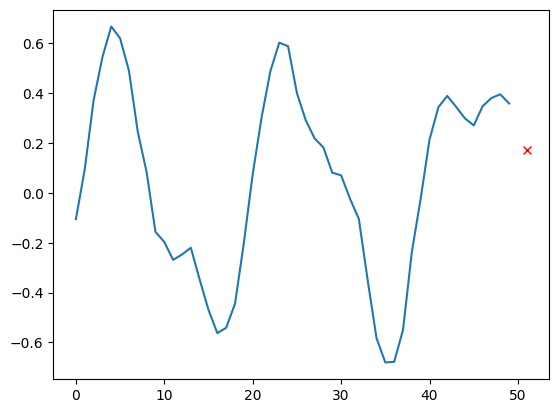

In [48]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [49]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [50]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [51]:
model_linear.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2179 - mean_squared_error: 0.2179 - val_loss: 0.1062 - val_mean_squared_error: 0.1062
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0691 - mean_squared_error: 0.0691 - val_loss: 0.0443 - val_mean_squared_error: 0.0443
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0336 - mean_squared_error: 0.0336 - val_loss: 0.0243 - val_mean_squared_error: 0.0243
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0203 - mean_squared_error: 0.0203 - val_loss: 0.0157 - val_mean_squared_error: 0.0157
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0119 - val_mean_squared_error: 0.0119


In [53]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

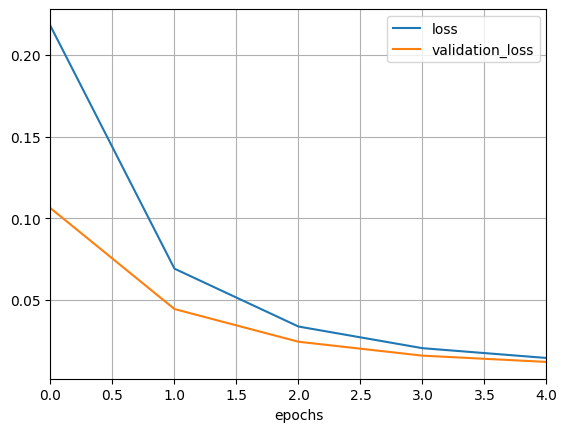

In [54]:
plot_function(history_linear)

In [55]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.011722837574779987
Test MSE:  0.011722837574779987


### 1.5 Simple RNN Model

In [56]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [57]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [58]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.4386 - mean_squared_error: 0.4386 - val_loss: 0.3140 - val_mean_squared_error: 0.3140
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2598 - mean_squared_error: 0.2598 - val_loss: 0.2601 - val_mean_squared_error: 0.2601
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2201 - mean_squared_error: 0.2201 - val_loss: 0.2146 - val_mean_squared_error: 0.2146
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1796 - mean_squared_error: 0.1796 - val_loss: 0.1711 - val_mean_squared_error: 0.1711
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1493 - mean_squared_error: 0.1493 - val_loss: 0.1464 - val_mean_squared_error: 0.1464


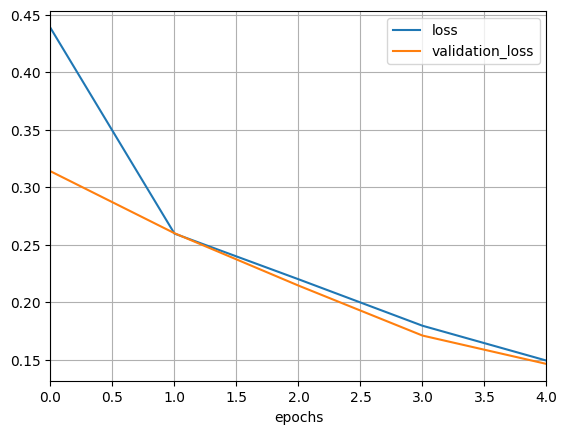

In [59]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [60]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [61]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [62]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0670 - mean_squared_error: 0.0670 - val_loss: 0.0164 - val_mean_squared_error: 0.0164
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0082 - val_mean_squared_error: 0.0082
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0060 - val_mean_squared_error: 0.0060
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0053 - val_mean_squared_error: 0.0053
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0045 - val_mean_squared_error: 0.0045


In [63]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.004563345108181238
Test MSE:  0.004563345108181238


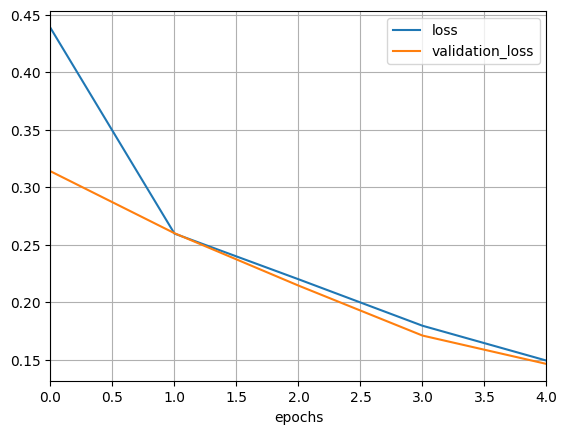

In [64]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [65]:
#from keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [66]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

### 2.2 - Dataset examination

In [67]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [68]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [69]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [70]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [71]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [72]:
optimizer = Adam(learning_rate = 0.001)

In [73]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [74]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4942 - loss: 0.7203 - val_accuracy: 0.4898 - val_loss: 0.6988
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5016 - loss: 0.6996 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4941 - loss: 0.6964 - val_accuracy: 0.5062 - val_loss: 0.6939
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4965 - loss: 0.6964 - val_accuracy: 0.5062 - val_loss: 0.6932
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5008 - loss: 0.6954 - val_accuracy: 0.4938 - val_loss: 0.6943


In [75]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6938070058822632
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

network LSTM:

In [76]:
embed_size = 128
vocabulary_size = 1000

model1 = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

optimizer1 = Adam(learning_rate = 0.001)

model1.compile(loss="binary_crossentropy", optimizer=optimizer1, metrics=["accuracy"])

history = model1.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5688 - loss: 0.6739 - val_accuracy: 0.6536 - val_loss: 0.6538
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7534 - loss: 0.5198 - val_accuracy: 0.7628 - val_loss: 0.4908
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8049 - loss: 0.4323 - val_accuracy: 0.8064 - val_loss: 0.4264
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8171 - loss: 0.4035 - val_accuracy: 0.8122 - val_loss: 0.4182
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8319 - loss: 0.3764 - val_accuracy: 0.8236 - val_loss: 0.4010


In [77]:
score2 = model1.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score2[0])
print(f'Test accuracy: ', score2[1]*100, "%")

Test loss: 0.3881586790084839
Test accuracy:  82.6799988746643 %


GRU network:

In [78]:
embed_size = 128
vocabulary_size = 1000

model2 = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

optimizer2 = Adam(learning_rate = 0.001)

model2.compile(loss="binary_crossentropy", optimizer=optimizer2, metrics=["accuracy"])

history = model2.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5225 - loss: 0.6958 - val_accuracy: 0.4938 - val_loss: 0.6985
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6809 - loss: 0.5742 - val_accuracy: 0.7830 - val_loss: 0.4563
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8083 - loss: 0.4184 - val_accuracy: 0.8118 - val_loss: 0.4095
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8379 - loss: 0.3649 - val_accuracy: 0.8128 - val_loss: 0.4079
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8500 - loss: 0.3426 - val_accuracy: 0.8274 - val_loss: 0.3870


In [79]:
score3 = model2.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score3[0])
print(f'Test accuracy: ', score3[1]*100, "%")

Test loss: 0.3790230453014374
Test accuracy:  82.6479971408844 %


testing best acuracy

In [80]:
embed_size = 128
vocabulary_size = 1000

model3 = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
     keras.layers.GRU(128, return_sequences=True),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

optimizer3 = Adam(learning_rate = 0.001)

model3.compile(loss="binary_crossentropy", optimizer=optimizer3, metrics=["accuracy"])

history = model3.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5769 - loss: 0.6584 - val_accuracy: 0.7398 - val_loss: 0.5786
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8127 - loss: 0.4131 - val_accuracy: 0.8270 - val_loss: 0.3921
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8446 - loss: 0.3520 - val_accuracy: 0.8396 - val_loss: 0.3717
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8551 - loss: 0.3301 - val_accuracy: 0.8236 - val_loss: 0.3998
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8638 - loss: 0.3124 - val_accuracy: 0.8372 - val_loss: 0.3845
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8709 - loss: 0.2949 - val_accuracy: 0.8336 - val_loss: 0.3873
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.8800 - loss: 0.2792 - val_accuracy: 0.8258 - val_loss: 0.4057
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8897 - loss: 0.2595 - 

In [81]:
scorebest = model3.evaluate(X_test, y_test, verbose=0)
print('Test loss:', scorebest[0])
print(f'Test accuracy: ', scorebest[1]*100, "%")

Test loss: 0.45922526717185974
Test accuracy:  81.94800019264221 %
